<a href="https://colab.research.google.com/github/manu93jadon/CI-CD-Project/blob/master/IPL_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Download dataset and load in df

In [ ]:
import pandas as pd
import urllib.request
url = 'https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/158/850/original/IPL_2008-2024.csv?1760202529'
output_file = 'ipldata.csv'

# Download the file
urllib.request.urlretrieve(url, output_file)
print(f"Downloaded data to {output_file}")

ipl_df = pd.read_csv(output_file)

Downloaded data to ipldata.csv


#Import Section

In [ ]:
import numpy as np

# 1 ) Data Preprocessing & Feature Engineering
Prepare the IPL dataset through cleaning, exploratory analysis, and creation of meaningful new features that capture match dynamics.

In [ ]:
ipl_df.shape

(1095, 20)

In [ ]:
ipl_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   int64  
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [ ]:
ipl_df.describe()

,id,season,result_margin,target_runs,target_overs
count,1.095000e+03,1095.000000,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,2016.126027,17.259294,165.684066,19.759341
std,3.677402e+05,4.946940,21.787444,33.427048,1.581108
min,3.359820e+05,2008.000000,1.000000,43.000000,5.000000
25%,5.483315e+05,2012.000000,6.000000,146.000000,20.000000
50%,9.809610e+05,2016.000000,8.000000,166.000000,20.000000
75%,1.254062e+06,2021.000000,20.000000,187.000000,20.000000
max,1.426312e+06,2024.000000,146.000000,288.000000,20.000000


In [ ]:
# Check for missing values in each column
missing_values=ipl_df.isnull().sum().sort_values(ascending=False)
print(missing_values)

method             1074
city                 51
result_margin        19
player_of_match       5
winner                5
target_runs           3
target_overs          3
id                    0
date                  0
season                0
venue                 0
match_type            0
toss_decision         0
toss_winner           0
team2                 0
team1                 0
result                0
super_over            0
umpire1               0
umpire2               0
dtype: int64


In [ ]:
#Check for unique values in each column
unique_values=ipl_df.nunique().sort_values(ascending=False)
print(unique_values)

id                 1095
date                823
player_of_match     291
target_runs         170
result_margin        98
umpire1              62
umpire2              62
venue                58
city                 36
toss_winner          19
team1                19
team2                19
winner               19
season               17
target_overs         15
match_type            8
result                4
toss_decision         2
super_over            2
method                1
dtype: int64


In [ ]:
ipl_df.value_counts("venue")

,count
venue,
Eden Gardens,77
Wankhede Stadium,73
M Chinnaswamy Stadium,65
Feroz Shah Kotla,60
"Rajiv Gandhi International Stadium, Uppal",49
"MA Chidambaram Stadium, Chepauk",48
Sawai Mansingh Stadium,47
Dubai International Cricket Stadium,46
"Wankhede Stadium, Mumbai",45


In [ ]:
#Checking city along with Venue to confirm if some venue names are duplicated here
ipl_df.groupby("venue")["city"].value_counts("venue").sort_values(ascending=False)

,,proportion
venue,city,
Arun Jaitley Stadium,Delhi,1.00
"Arun Jaitley Stadium, Delhi",Delhi,1.00
Barabati Stadium,Cuttack,1.00
"Barsapara Cricket Stadium, Guwahati",Guwahati,1.00
"Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow",Lucknow,1.00
Brabourne Stadium,Mumbai,1.00
"Brabourne Stadium, Mumbai",Mumbai,1.00
Buffalo Park,East London,1.00
De Beers Diamond Oval,Kimberley,1.00


## Observation 1- Multiple Venues are listed duplicated, some are renames and some are duplicated due to city name along with their names, we will standardise this.

In [ ]:
ipl_df.value_counts("city")

,count
city,
Mumbai,173
Kolkata,93
Delhi,90
Chennai,85
Hyderabad,77
Bangalore,65
Chandigarh,61
Jaipur,57
Pune,51


## Observation 2 - Some City names are duplicated like Bengaluru and Banglore, we will standardise this as well.

In [ ]:
ipl_df.value_counts("team1")

,count
team1,
Royal Challengers Bangalore,135
Chennai Super Kings,128
Mumbai Indians,123
Kolkata Knight Riders,121
Rajasthan Royals,101
Kings XI Punjab,92
Sunrisers Hyderabad,86
Delhi Daredevils,85
Delhi Capitals,41


## Observation 3 - Duplicates are caused here by:
  

*   Some team name changes like Delhi Daredevils to Delhi Capitals, Royal Challengers Bengalore  to Royal Challengers Bengaluru
*   Rising Pune Supergiant and Rising Pune Supergiants , minor spelling change

In [ ]:
ipl_df.value_counts("match_type")

,count
match_type,
League,1029
Final,17
Qualifier 1,14
Qualifier 2,14
Eliminator,11
Semi Final,6
Elimination Final,3
3rd Place Play-Off,1


In [ ]:
ipl_df.value_counts("method")

,count
method,
D/L,21


## Observation 4- Only one value of method - D/L, we will rather create one column like DL_used - Yes or No

In [ ]:
# Null values analysis
null_city_rows = ipl_df[ipl_df['city'].isnull()]
null_method_rows = ipl_df[ipl_df['method'].isnull()]
null_winner_rows = ipl_df[ipl_df['winner'].isnull()]
null_result_margin_rows = ipl_df[ipl_df['result_margin'].isnull()]
null_player_of_match_rows = ipl_df[ipl_df['player_of_match'].isnull()]
null_target_runs_rows = ipl_df[ipl_df['target_runs'].isnull()]
null_target_overs_rows = ipl_df[ipl_df['target_overs'].isnull()]

display("1 ) null_city_rows")
display(null_city_rows)

display("2 ) null_method_rows")
display(null_method_rows)

display("3 ) null_winner_rows")
display(null_winner_rows)

display("4) null_result_margin_rows")
display(null_result_margin_rows)

display("5 ) null_player_of_match_rows")
display(null_player_of_match_rows)

display("6 ) null_target_runs_rows")
display(null_target_runs_rows)

display("7 ) null_target_overs_rows")
display(null_target_overs_rows)

'1 ) null_city_rows'

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
399,729281,2014,NaN,2014-04-17,League,YS Chahal,Sharjah Cricket Stadium,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,Royal Challengers Bangalore,wickets,8.0,146.0,20.0,N,NaN,Aleem Dar,S Ravi
402,729287,2014,NaN,2014-04-19,League,PA Patel,Dubai International Cricket Stadium,Royal Challengers Bangalore,Mumbai Indians,Royal Challengers Bangalore,field,Royal Challengers Bangalore,wickets,7.0,116.0,20.0,N,NaN,Aleem Dar,AK Chaudhary
403,729289,2014,NaN,2014-04-19,League,JP Duminy,Dubai International Cricket Stadium,Kolkata Knight Riders,Delhi Daredevils,Kolkata Knight Riders,bat,Delhi Daredevils,wickets,4.0,167.0,20.0,N,NaN,Aleem Dar,VA Kulkarni
404,729291,2014,NaN,2014-04-20,League,GJ Maxwell,Sharjah Cricket Stadium,Rajasthan Royals,Kings XI Punjab,Kings XI Punjab,field,Kings XI Punjab,wickets,7.0,192.0,20.0,N,NaN,BF Bowden,M Erasmus
406,729295,2014,NaN,2014-04-22,League,GJ Maxwell,Sharjah Cricket Stadium,Kings XI Punjab,Sunrisers Hyderabad,Sunrisers Hyderabad,field,Kings XI Punjab,runs,72.0,194.0,20.0,N,NaN,M Erasmus,S Ravi
407,729297,2014,NaN,2014-04-23,League,RA Jadeja,Dubai International Cricket Stadium,Rajasthan Royals,Chennai Super Kings,Rajasthan Royals,field,Chennai Super Kings,runs,7.0,141.0,20.0,N,NaN,HDPK Dharmasena,RK Illingworth
408,729299,2014,NaN,2014-04-24,League,CA Lynn,Sharjah Cricket Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,2.0,151.0,20.0,N,NaN,Aleem Dar,VA Kulkarni
409,729301,2014,NaN,2014-04-25,League,AJ Finch,Dubai International Cricket Stadium,Sunrisers Hyderabad,Delhi Daredevils,Sunrisers Hyderabad,bat,Sunrisers Hyderabad,runs,4.0,185.0,20.0,N,NaN,M Erasmus,S Ravi
410,729303,2014,NaN,2014-04-25,League,MM Sharma,Dubai International Cricket Stadium,Chennai Super Kings,Mumbai Indians,Mumbai Indians,bat,Chennai Super Kings,wickets,7.0,142.0,20.0,N,NaN,BF Bowden,M Erasmus
413,729309,2014,NaN,2014-04-27,League,M Vijay,Sharjah Cricket Stadium,Delhi Daredevils,Mumbai Indians,Mumbai Indians,bat,Delhi Daredevils,wickets,6.0,126.0,20.0,N,NaN,Aleem Dar,VA Kulkarni


'2 ) null_method_rows'

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,4.0,215.0,20.0,N,NaN,Nitin Menon,VK Sharma
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,160.0,20.0,N,NaN,AK Chaudhary,R Pandit
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,4.0,173.0,20.0,N,NaN,KN Ananthapadmanabhan,MV Saidharshan Kumar
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,36.0,176.0,20.0,N,NaN,Nitin Menon,VK Sharma


'3 ) null_winner_rows'

...

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
241,501265,2011,Delhi,2011-05-21,League,NaN,Feroz Shah Kotla,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,NaN,no result,NaN,NaN,NaN,N,NaN,SS Hazare,RJ Tucker
485,829763,2015,Bangalore,2015-04-29,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,NaN,NaN,N,NaN,JD Cloete,PG Pathak
511,829813,2015,Bangalore,2015-05-17,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,field,NaN,no result,NaN,188.0,20.0,N,NaN,HDPK Dharmasena,K Srinivasan
744,1178424,2019,Bengaluru,2019-04-30,League,NaN,M.Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,63.0,5.0,N,NaN,NJ Llong,UV Gandhe
994,1359519,2023,Lucknow,2023-05-03,League,NaN,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Chennai Super Kings,Chennai Super Kings,field,NaN,no result,NaN,NaN,NaN,N,NaN,AK Chaudhary,NA Patwardhan


'6 ) null_target_runs_rows'

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
241,501265,2011,Delhi,2011-05-21,League,NaN,Feroz Shah Kotla,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,NaN,no result,NaN,NaN,NaN,N,NaN,SS Hazare,RJ Tucker
485,829763,2015,Bangalore,2015-04-29,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,NaN,NaN,N,NaN,JD Cloete,PG Pathak
994,1359519,2023,Lucknow,2023-05-03,League,NaN,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Chennai Super Kings,Chennai Super Kings,field,NaN,no result,NaN,NaN,NaN,N,NaN,AK Chaudhary,NA Patwardhan


'7 ) null_target_overs_rows'

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
241,501265,2011,Delhi,2011-05-21,League,NaN,Feroz Shah Kotla,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,NaN,no result,NaN,NaN,NaN,N,NaN,SS Hazare,RJ Tucker
485,829763,2015,Bangalore,2015-04-29,League,NaN,M Chinnaswamy Stadium,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,NaN,no result,NaN,NaN,NaN,N,NaN,JD Cloete,PG Pathak
994,1359519,2023,Lucknow,2023-05-03,League,NaN,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow Super Giants,Chennai Super Kings,Chennai Super Kings,field,NaN,no result,NaN,NaN,NaN,N,NaN,AK Chaudhary,NA Patwardhan


## Observation 5 - Missing Values Explanation:


> a) Method
- 1074 values missing - This is expected as if match was played interrupted ,like rain, only then sometime D/L is applied, else method is null , what we can do maybe  change column to yes/no kind of column, like if_dl.



> b ) city

- 51 values missing - Data Error - Matches were Played in 2014 and 2020 in Sharjah , Abudhabi and Dubai International UAE, we can fill missing values as per city mapping
> c ) result_margin
- 19 values missing - Matches without result - either "Tie"(14) or "no result" (5) won't have any result margin. We can split into runs and wickets columns with NaN where not applicable, and no-result rows would be only be kept in the master dataset and filtered per analysis.
> d ) player_of_match
- 5 rows - "No result rows"
> e ) winner
- 5 rows - "No result rows" same as above      
>f ) target_runs
- "No result rows" where no overs could be played at all
>g ) target_over
- "No result rows" where no overs could be played at all

## Standardising Columns and Fixing Missing Values

In [ ]:
import pandas as pd

# 1. Standardise differently listed Venue Names
standard_venues = {
    # Bengaluru
    "M.Chinnaswamy Stadium": "M Chinnaswamy Stadium",
    "M Chinnaswamy Stadium, Bengaluru": "M Chinnaswamy Stadium",

    # Chennai
    "MA Chidambaram Stadium, Chepauk": "MA Chidambaram Stadium",
    "MA Chidambaram Stadium, Chepauk, Chennai": "MA Chidambaram Stadium",

    # Delhi
    "Arun Jaitley Stadium, Delhi": "Arun Jaitley Stadium",
    "Feroz Shah Kotla": "Arun Jaitley Stadium",

    # Mumbai & Navi Mumbai
    "Wankhede Stadium, Mumbai": "Wankhede Stadium",
    "Brabourne Stadium, Mumbai": "Brabourne Stadium",
    "Dr DY Patil Sports Academy, Mumbai": "Dr DY Patil Sports Academy",

    # Chandigarh / Mohali
    "Punjab Cricket Association Stadium, Mohali": "Punjab Cricket Association IS Bindra Stadium",
    "Punjab Cricket Association IS Bindra Stadium, Mohali": "Punjab Cricket Association IS Bindra Stadium",
    "Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh": "Punjab Cricket Association IS Bindra Stadium",

    # Hyderabad
    "Rajiv Gandhi International Stadium, Uppal": "Rajiv Gandhi International Stadium",
    "Rajiv Gandhi International Stadium, Uppal, Hyderabad": "Rajiv Gandhi International Stadium",

    # Pune
    "Maharashtra Cricket Association Stadium, Pune": "Maharashtra Cricket Association Stadium",
    "Subrata Roy Sahara Stadium": "Maharashtra Cricket Association Stadium",

    # Ahmedabad
    "Narendra Modi Stadium, Ahmedabad": "Narendra Modi Stadium",
    "Sardar Patel Stadium, Motera": "Narendra Modi Stadium",

    # Kolkata
    "Eden Gardens, Kolkata": "Eden Gardens",

    # Jaipur
    "Sawai Mansingh Stadium, Jaipur": "Sawai Mansingh Stadium",

    # Dharamsala
    "Himachal Pradesh Cricket Association Stadium, Dharamsala": "Himachal Pradesh Cricket Association Stadium",

    # Visakhapatnam
    "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam": "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium",

    # Abu Dhabi
    "Zayed Cricket Stadium, Abu Dhabi": "Sheikh Zayed Stadium",
    "Zayed Cricket Stadium": "Sheikh Zayed Stadium",

    #Comma Separated
    "Barsapara Cricket Stadium, Guwahati": "Barsapara Cricket Stadium",
    "Vidarbha Cricket Association Stadium, Jamtha": "Vidarbha Cricket Association Stadium",
    "Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow": "Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium"
}

# 2. Fix the city inconsistencies alongside the venue clean-up
standard_cities = {
    "Bangalore": "Bengaluru",
    "Navi Mumbai": "Mumbai"
}

# Step A: Clean up the trailing/leading whitespaces
ipl_df['venue'] = ipl_df['venue'].str.strip()
ipl_df['city'] = ipl_df['city'].str.strip()

# Step B: Map the duplicates to their standard names
ipl_df['venue'] = ipl_df['venue'].replace(standard_venues)
ipl_df['city'] = ipl_df['city'].replace(standard_cities)

# Step C: Fix the specific PCA Mohali city classification (from Chandigarh to Mohali)
ipl_df.loc[ipl_df['venue'] == 'Punjab Cricket Association IS Bindra Stadium', 'city'] = 'Mohali'
# Step D: Verifying unique counts now
cleaned_grouped = ipl_df.groupby("venue")["city"].value_counts().sort_values(ascending=False)
print(cleaned_grouped)


venue                                                               city          
Wankhede Stadium                                                    Mumbai            118
M Chinnaswamy Stadium                                               Bengaluru          94
Eden Gardens                                                        Kolkata            93
Arun Jaitley Stadium                                                Delhi              90
MA Chidambaram Stadium                                              Chennai            85
Rajiv Gandhi International Stadium                                  Hyderabad          77
Punjab Cricket Association IS Bindra Stadium                        Mohali             61
Sawai Mansingh Stadium                                              Jaipur             57
Maharashtra Cricket Association Stadium                             Pune               51
Dr DY Patil Sports Academy                                          Mumbai             37
Sheikh Zayed Stad

In [ ]:
# 1. Fix Team names inconsistencies  - mapping dictionary for IPL franchises:
standard_teams = {
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings",
    "Rising Pune Supergiants": "Rising Pune Supergiant",
}
# 1. Clean team name columns
ipl_df[['team1', 'team2', 'toss_winner', 'winner']] = ipl_df[['team1', 'team2', 'toss_winner', 'winner']].apply(lambda x: x.str.strip().replace(standard_teams))

# 2. Get value counts now
print(ipl_df[['team1', 'team2', 'toss_winner', 'winner']].apply(pd.Series.value_counts).sort_values(by='team1', ascending=False))



                             team1  team2  toss_winner  winner
Royal Challengers Bengaluru    144    111          121     123
Chennai Super Kings            128    110          122     138
Delhi Capitals                 126    126          130     115
Mumbai Indians                 123    138          143     144
Punjab Kings                   123    123          109     112
Kolkata Knight Riders          121    130          122     131
Rajasthan Royals               101    120          120     112
Sunrisers Hyderabad             86     96           88      88
Deccan Chargers                 39     36           43      29
Pune Warriors                   23     23           20      12
Lucknow Super Giants            23     21           19      24
Gujarat Titans                  21     24           22      28
Gujarat Lions                   16     14           15      13
Rising Pune Supergiant          14     16           13      15
Kochi Tuskers Kerala             7      7            8 

In [ ]:
# Initialize the venue to city mapping dictionary
venue_to_city_map = {}

# Manually add mappings for the UAE venues that have all missing cities in 2014 or 2020
venue_to_city_map['Sharjah Cricket Stadium'] = 'Sharjah'
venue_to_city_map['Dubai International Cricket Stadium'] = 'Dubai'
venue_to_city_map['Sheikh Zayed Stadium'] = 'Abu Dhabi'

# 2. Fill missing city values using the map
ipl_df['city'] = ipl_df['city'].fillna(ipl_df['venue'].map(venue_to_city_map))

# 3. Verify that there are no more missing values in the 'city' column
missing_cities_count = ipl_df['city'].isnull().sum()
print(f"Missing cities: {missing_cities_count}")

Missing cities: 0


In [ ]:
# Convert date column to datetime format
ipl_df['date'] = pd.to_datetime(ipl_df['date'])
ipl_df['date'].dtype

dtype('<M8[ns]')

In [ ]:
ipl_df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2008,Bengaluru,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2008,Mohali,2008-04-19,League,MEK Hussey,Punjab Cricket Association IS Bindra Stadium,Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2008,Delhi,2008-04-19,League,MF Maharoof,Arun Jaitley Stadium,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2008,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2008,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [ ]:
ipl_df.value_counts("result")

,count
result,
wickets,578
runs,498
tie,14
no result,5


In [ ]:
# Split result_margin into result_margin_runs and result_margin_wickets as value is very different in case of wickets or run victory
ipl_df['result_margin_runs'] = np.where(
    ipl_df['result'] == "runs",
    ipl_df['result_margin'],
    np.nan
)
ipl_df['result_margin_wickets'] = np.where(
    ipl_df['result'] == "wickets",
    ipl_df['result_margin'],
    np.nan
)

# Display sample of the split columns
print(ipl_df[['result', 'result_margin', 'result_margin_runs', 'result_margin_wickets']].head())

    result  result_margin  result_margin_runs  result_margin_wickets
0     runs          140.0               140.0                    NaN
1     runs           33.0                33.0                    NaN
2  wickets            9.0                 NaN                    9.0
3  wickets            5.0                 NaN                    5.0
4  wickets            5.0                 NaN                    5.0


### Note - Though this has created NaNs, we need it by design, if I give 0 , it will impact average.

In [ ]:
#Handling D/L flag:
ipl_df['is_dl']=np.where(ipl_df['method'].isnull(),0,1)
ipl_df['is_dl'].value_counts()

,count
is_dl,
0,1074
1,21


In [ ]:
# Compare D/L flag against shortened matches
pd.crosstab(ipl_df['is_dl'], ipl_df['target_overs'] < 20,
            rownames=['is_dl'], colnames=['shortened'])


shortened,False,True
is_dl,,
0,1065,9
1,0,21


In [ ]:
ipl_df['is_shortened'] = np.where(ipl_df['target_overs'] < 20, 1, 0)

In [ ]:
# match_importance: league / playoff / final
ipl_df['match_importance'] = np.where(
    ipl_df['match_type'] == 'League', 'league',
    np.where(ipl_df['match_type'] == 'Final', 'final', 'playoff')
)
ipl_df['match_importance'].value_counts()

,count
match_importance,
league,1029
playoff,49
final,17


In [ ]:
# Season phase: split each season into thirds by match order.
ipl_df = ipl_df.sort_values(['date', 'id']).reset_index(drop=True)

# Match number within each season
ipl_df['match_number'] = ipl_df.groupby('season').cumcount() + 1

# Split each season into 3 equal-count bins: 0 = early, 1 = mid, 2 = late
phase = ipl_df.groupby('season')['match_number'].transform(
    lambda x: pd.qcut(x, q=3, labels=False)
)
ipl_df['season_phase'] = phase.map({0: 'early', 1: 'mid', 2: 'late'})

# Check: each season should be split roughly into thirds
pd.crosstab(ipl_df['season'], ipl_df['season_phase'])


season_phase,early,late,mid
season,,,
2008,19,20,19
2009,19,19,19
2010,20,20,20
2011,24,25,24
2012,25,25,24
2013,25,26,25
2014,20,20,20
2015,20,20,19
2016,20,20,20


In [ ]:
#Toss Advantage - Check if winner and toss winner are same
ipl_df['toss_advantage'] = np.where(
    ipl_df['winner'].isnull(), np.nan,
    np.where(ipl_df['toss_winner'] == ipl_df['winner'], 1, 0)
)

In [ ]:
#Home Advantage Check
team_home_city = {
    # Franchises home team mapping some are  Multi-City / Alternate Home Grounds
    "Rajasthan Royals": ["Jaipur", "Guwahati"],
    "Punjab Kings": ["Mohali", "Dharamsala", "Indore", "Cuttack"],
    "Delhi Capitals": ["Delhi", "Visakhapatnam", "Raipur"],
    "Chennai Super Kings": ["Chennai", "Pune", "Ranchi"],
    "Royal Challengers Bengaluru": ["Bengaluru"],
    "Mumbai Indians": ["Mumbai"],
    "Kolkata Knight Riders": ["Kolkata"],
    "Sunrisers Hyderabad": ["Hyderabad"],
    "Lucknow Super Giants": ["Lucknow"],
    "Gujarat Titans": ["Ahmedabad"],
    "Deccan Chargers": ["Hyderabad", "Visakhapatnam"],
    "Gujarat Lions": ["Rajkot", "Kanpur"],
    "Pune Warriors": ["Pune"],
    "Rising Pune Supergiant": ["Pune"],
    "Kochi Tuskers Kerala": ["Kochi"]
}
def is_home(team, city):
    return int(city in team_home_city.get(team, []))

ipl_df['team1_home'] = ipl_df.apply(lambda r: is_home(r['team1'], r['city']), axis=1)
ipl_df['team2_home'] = ipl_df.apply(lambda r: is_home(r['team2'], r['city']), axis=1)


In [ ]:
# A match can't be home for both teams
both_home = ipl_df[(ipl_df['team1_home'] == 1) & (ipl_df['team2_home'] == 1)]
both_home[['season', 'city', 'team1', 'team2']]

,season,city,team1,team2
263,2012,Pune,Pune Warriors,Chennai Super Kings
363,2013,Pune,Pune Warriors,Chennai Super Kings


In [ ]:
#In 2012 and 2013, Pune was home for Pune Warriors, not for CSK. CSK only used Pune as a home ground in 2018.

#Fix - Treat Pune as a CSK home city only in 2018:
csk_pune_not_home = (ipl_df['city'] == 'Pune') & (ipl_df['season'] != 2018)
ipl_df.loc[csk_pune_not_home & (ipl_df['team1'] == 'Chennai Super Kings'), 'team1_home'] = 0
ipl_df.loc[csk_pune_not_home & (ipl_df['team2'] == 'Chennai Super Kings'), 'team2_home'] = 0

#Check again:
both_home = ipl_df[(ipl_df['team1_home'] == 1) & (ipl_df['team2_home'] == 1)]
both_home[['season', 'city', 'team1', 'team2']]

,season,city,team1,team2


In [ ]:
# How many teams were "at home" in each match: 0, 1
home_count = ipl_df['team1_home'] + ipl_df['team2_home']

pd.crosstab(ipl_df['season'], home_count,
            rownames=['season'], colnames=['home_teams'])

home_teams,0,1
season,,
2008,3,55
2009,57,0
2010,11,49
2011,9,64
2012,4,70
2013,6,70
2014,27,33
2015,14,45
2016,6,54


## Observation 6 – Home advantage
Home cities are mapped per franchise, including secondary grounds (e.g. Punjab Kings at Dharamsala/Indore, Rajasthan Royals at Guwahati). A season-specific exception is applied for Chennai Super Kings in Pune, which was a CSK home ground only in 2018. In 2012–13 it belonged to Pune Warriors.
2009 (South Africa), 2020 (UAE) and 2021 are neutral seasons, so no team is marked as home. The 2021 result comes from the data itself, since teams didn't play in their home cities.
2022 was officially held at neutral venues in Mumbai and Pune, but Mumbai Indians' matches in Mumbai are kept as home games, on the assumption that a familiar city and crowd still give some advantage.
Limitation: a small number of league matches may be misclassified where a team used a secondary home ground missing from the mapping. Given how few matches this affects out of 1,095, the impact on the analysis is expected to be minimal.

## Venue Advantage  - venue_matches_team1_prior and venue_matches_team2_prior

Approach - We would concatenate id,team, venue and team to create another df so that we can then sort based on date , groupby based on 'team' 'venue' to get cumulative count of each team+value combination.

In [ ]:
# 1. one row per (match, team) in long format
long_df = pd.concat([
    ipl_df[['id', 'date', 'venue', 'team1']].rename(columns={'team1': 'team'}),
    ipl_df[['id', 'date', 'venue', 'team2']].rename(columns={'team2': 'team'}),
])

# 2. Sort chronologically, then count prior appearances per team at each venue
long_df = long_df.sort_values(['date', 'id'])
long_df['venue_prior'] = long_df.groupby(['team', 'venue']).cumcount()

# 3. Join back for team1 and for team2
ipl_df = ipl_df.merge(
    long_df.rename(columns={'team': 'team1', 'venue_prior': 'venue_matches_team1_prior'})[['id', 'team1', 'venue_matches_team1_prior']],
    on=['id', 'team1'], how='left')
ipl_df = ipl_df.merge(
    long_df.rename(columns={'team': 'team2', 'venue_prior': 'venue_matches_team2_prior'})[['id', 'team2', 'venue_matches_team2_prior']],
    on=['id', 'team2'], how='left')
#Check for nulls left
print(ipl_df['venue_matches_team1_prior'].isnull().sum())
print(ipl_df['venue_matches_team2_prior'].isnull().sum())

print(f"Rows: {len(ipl_df)}")   # should be 1095

# Spot-check: Mumbai Indians at Wankhede — counts should run 0, 1, 2, ...
mi_wk = ipl_df[(ipl_df['venue'] == 'Wankhede Stadium') &
               ((ipl_df['team1'] == 'Mumbai Indians') | (ipl_df['team2'] == 'Mumbai Indians'))]
mi_wk[['date', 'team1', 'team2', 'venue_matches_team1_prior', 'venue_matches_team2_prior']].head(8)

0
0
Rows: 1095


,date,team1,team2,venue_matches_team1_prior,venue_matches_team2_prior
3,2008-04-20,Mumbai Indians,Royal Challengers Bengaluru,0,0
35,2008-05-14,Mumbai Indians,Chennai Super Kings,1,0
37,2008-05-16,Mumbai Indians,Kolkata Knight Riders,2,0
44,2008-05-21,Mumbai Indians,Punjab Kings,3,0
187,2011-04-15,Mumbai Indians,Kochi Tuskers Kerala,4,0
194,2011-04-20,Mumbai Indians,Pune Warriors,5,0
197,2011-04-22,Mumbai Indians,Chennai Super Kings,6,2
213,2011-05-02,Mumbai Indians,Punjab Kings,7,2


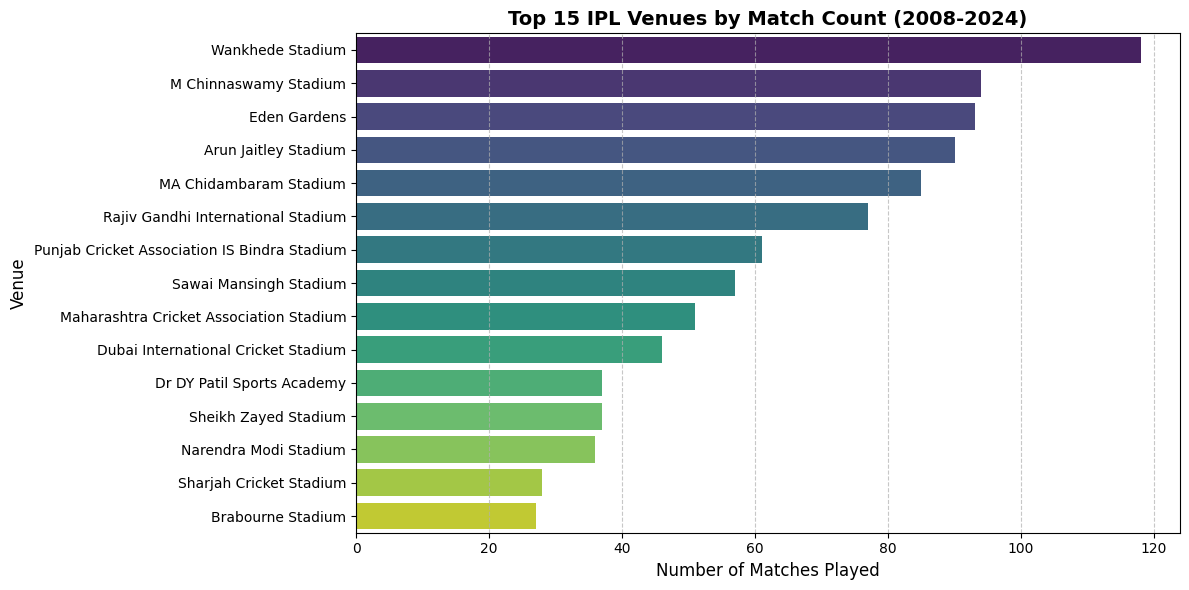

In [ ]:
# Venue distribution chart
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate venue match counts
venue_counts = ipl_df['venue'].value_counts().reset_index()
venue_counts.columns = ['Venue', 'Match Count']

# Plotting the top 15 most frequent venues
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Match Count',
    y='Venue',
    data=venue_counts.head(15),
    hue='Venue',
    palette='viridis',
    legend=False
)

plt.title('Top 15 IPL Venues by Match Count (2008-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Matches Played', fontsize=12)
plt.ylabel('Venue', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Matches are concentrated at a handful of grounds. Wankhede Stadium (118) leads, followed by M Chinnaswamy, Eden Gardens, Arun Jaitley and MA Chidambaram, at around 85–95 each. These are long-standing franchise home grounds. Seasons played partly or wholly outside India (2009 in South Africa; 2014, 2020 and part of 2021 in the UAE) added foreign venues with fewer matches.

In [ ]:
#In which season Wankhede Hosted most of the matches
ipl_df_wankhede = ipl_df[ipl_df['venue'] == 'Wankhede Stadium']
wankhede_matches_by_season = ipl_df_wankhede.groupby('season')['id'].count().reset_index()
wankhede_matches_by_season.columns = ['Season', 'Matches']
print(wankhede_matches_by_season)

    Season  Matches
0     2008        6
1     2011        9
2     2012        8
3     2013        8
4     2014        6
5     2015        8
6     2016        4
7     2017        8
8     2018        9
9     2019        7
10    2021       10
11    2022       21
12    2023        7
13    2024        7


In [ ]:
#As we can see above 2021 and 2022 is where we see Wankhede hosted most matches.
# Let us check for those two seasons what all stadiums were allowed to host IPL
ipl_df_season_2021 = ipl_df[ipl_df['season'] == 2021]
ipl_df_season_2022 = ipl_df[ipl_df['season'] == 2022]
ipl_df_season_2021_venues = ipl_df_season_2021['venue'].unique()
ipl_df_season_2022_venues = ipl_df_season_2022['venue'].unique()
print(f"IPL venues allowed in 2021: {ipl_df_season_2021_venues}")
print(f"IPL venues allowed in 2022: {ipl_df_season_2022_venues}")

IPL venues allowed in 2021: ['MA Chidambaram Stadium' 'Wankhede Stadium' 'Narendra Modi Stadium'
 'Arun Jaitley Stadium' 'Dubai International Cricket Stadium'
 'Sheikh Zayed Stadium' 'Sharjah Cricket Stadium']
IPL venues allowed in 2022: ['Wankhede Stadium' 'Brabourne Stadium' 'Dr DY Patil Sports Academy'
 'Maharashtra Cricket Association Stadium' 'Eden Gardens'
 'Narendra Modi Stadium']


###Observation – COVID-era seasons

In 2021, the India leg was restricted to four venues (MA Chidambaram, Wankhede, Narendra Modi and Arun Jaitley) before the season moved to the UAE. In 2022, the league stage was held at Mumbai and Pune venues to limit travel inside bio-bubbles, with playoffs in Kolkata and Ahmedabad.

Observation – Wankhede

Wankhede's 118 matches come mainly from being Mumbai Indians' home ground across almost every season. 2022 added an unusually high 21 matches, about 18% of its total.

## Toss Factor- Let us check average win percentage by toss winners

In [ ]:
# Win Percentage for toss winners

# Overall Toss Win to Match Win conversion rate
overall_toss_win_pct = ipl_df['toss_advantage'].mean() * 100
print(f"Overall Match Win Percentage for Toss Winners: {overall_toss_win_pct:.2f}%")

# Toss Win Percentage by Season
season_toss_win = ipl_df.groupby('season')['toss_advantage'].mean().reset_index()
season_toss_win['toss_advantage'] = season_toss_win['toss_advantage'] * 100
season_toss_win.columns = ['Season', 'Toss Winner Win %']

print("\nSeason-wise Toss Winner Win Percentage:")
display(season_toss_win.style.format({'Toss Winner Win %': '{:.2f}%'}).hide(axis='index'))

# Statistical summary of the season-wise win percentages
print("\nStatistical Summary:")
display(season_toss_win['Toss Winner Win %'].describe())

Overall Match Win Percentage for Toss Winners: 50.83%

Season-wise Toss Winner Win Percentage:


Season,Toss Winner Win %
2008,48.28%
2009,57.89%
2010,51.67%
2011,52.78%
2012,44.59%
2013,47.37%
2014,50.00%
2015,49.12%
2016,56.67%
2017,57.63%



Statistical Summary:


,Toss Winner Win %
count,17.000000
mean,51.131229
std,5.693568
min,41.666667
25%,47.368421
50%,50.000000
75%,56.666667
max,61.016949


### Toss Decision - It seems like winning toss doesn't favour the team, mean is almost 50 and each season wise too, win percentage stayed nearly 45-55, not a deciding factor.
Maybe toss_decision plays some role. Let us check that now

In [ ]:
# Win Percentage for toss winners by toss_decision

# Overall Toss Win to Match Win conversion rate by toss decision
toss_win_pct_by_decision = ipl_df.groupby('toss_decision')['toss_advantage'].mean() * 100
print("Overall Match Win Percentage for Toss Winners by Toss Decision:")
for decision, pct in toss_win_pct_by_decision.items():
    print(f"  {decision.capitalize()}: {pct:.2f}%")

# Toss Win Percentage by Season and toss_decision
season_decision_toss_win = ipl_df.groupby(['season', 'toss_decision'])['toss_advantage'].mean().reset_index()
season_decision_toss_win['toss_advantage'] = season_decision_toss_win['toss_advantage'] * 100
season_decision_toss_win.columns = ['Season', 'Toss Decision', 'Toss Winner Win %']

print("\nSeason-wise Toss Winner Win Percentage by Decision:")
display(season_decision_toss_win)

Overall Match Win Percentage for Toss Winners by Toss Decision:
  Bat: 45.38%
  Field: 53.86%

Season-wise Toss Winner Win Percentage by Decision:


,Season,Toss Decision,Toss Winner Win %
0,2008,bat,34.615385
1,2008,field,59.375000
2,2009,bat,54.285714
3,2009,field,63.636364
4,2010,bat,53.846154
5,2010,field,47.619048
6,2011,bat,45.833333
7,2011,field,56.250000
8,2012,bat,40.540541
9,2012,field,48.648649


In [ ]:
# Toss winner win % by venue, keeping only venues with enough matches to be meaningful
venue_toss = ipl_df.groupby('venue')['toss_advantage'].agg(['mean', 'count'])
venue_toss['mean'] = venue_toss['mean'] * 100
venue_toss.columns = ['Toss Winner Win %', 'Matches']

venue_toss_filtered = venue_toss[venue_toss['Matches'] >= 20].sort_values('Toss Winner Win %', ascending=False)
display(venue_toss_filtered)

,Toss Winner Win %,Matches
venue,,
Sharjah Cricket Stadium,57.142857,28
Maharashtra Cricket Association Stadium,54.901961,51
Dr DY Patil Sports Academy,54.054054,37
M Chinnaswamy Stadium,53.846154,91
Eden Gardens,52.688172,93
Sawai Mansingh Stadium,52.631579,57
Wankhede Stadium,52.542373,118
Brabourne Stadium,51.851852,27
Sheikh Zayed Stadium,51.351351,37


###Observation - Toss advantage by venue

Keeping venues with at least 20 matches, the toss-winner win % ranges from 36% to 57%. Rajiv Gandhi International Stadium (36%) and Dubai International Cricket Stadium stand out at the low end. Given the number of venues compared, this may partly be chance. These venues are worth examining in the Q6 toss-decision model

In [ ]:
from scipy.stats import chi2_contingency

# Does the toss decision affect whether the toss winner wins?
ct = pd.crosstab(ipl_df['toss_decision'], ipl_df['toss_advantage'])
chi2, p, dof, _ = chi2_contingency(ct)
print(ct)
print(f"\nChi-square p-value: {p:.4f}")

toss_advantage  0.0  1.0
toss_decision           
bat             213  177
field           323  377

Chi-square p-value: 0.0088


Observation – Toss decision

Overall, toss winners who chose to field won 53.9% of matches, versus 45.4% for those who chose to bat. The chi-square test (p = 0.0088) shows this difference is statistically significant, so fielding first has been the better choice on average.
Season-level swings, such as 2016, are based on small numbers of bat-first decisions and shouldn't be interpreted individually.

In [ ]:
# Final cleanup: drop raw columns replaced by engineered features
ipl_df = ipl_df.drop(columns=['result_margin', 'method'], errors='ignore')

# Remaining NaNs should only be the documented "not applicable" cases
ipl_df.isnull().sum()[ipl_df.isnull().sum() > 0]

,0
player_of_match,5
winner,5
target_runs,3
target_overs,3
result_margin_runs,597
result_margin_wickets,517
toss_advantage,5


## Q1 Summary – Notes & Assumptions

Data quality fixes

Franchise renames merged: Delhi Daredevils → Delhi Capitals, Kings XI Punjab → Punjab Kings, Royal Challengers Bangalore → Bengaluru, and both Rising Pune Supergiant spellings. Deccan Chargers and Sunrisers Hyderabad are kept separate, as are Gujarat Lions and Gujarat Titans (different franchises).
Venue name variants merged, including renames (Feroz Shah Kotla → Arun Jaitley, Subrata Roy Sahara → MCA Stadium, Sardar Patel Stadium, Motera → Narendra Modi Stadium, treated as one venue despite the rebuild).
City standardised: Bangalore → Bengaluru, Navi Mumbai → Mumbai, PCA Stadium → Mohali. The 51 missing cities (UAE matches) were filled from the venue.

Remaining NaNs (by design, meaning "not applicable")

winner, player_of_match, toss_advantage: the 5 no-result matches.
result_margin_runs / result_margin_wickets: one is always NaN, and both are NaN for ties and no-results.
target_runs / target_overs: 3 matches with no play.
No-result rows are kept in the master dataset and filtered per analysis.

Engineered features

is_dl: D/L applied. is_shortened: target overs < 20. Every D/L match is shortened, and 9 further matches were shortened without D/L.
match_importance: league / playoff / final, with all knockout matches grouped as playoff.
season_phase: each season split into equal thirds by match order.
team1_home / team2_home: per the home-advantage observation above.
venue_matches_team1_prior / team2_prior: matches at the venue before the current date, across all seasons.

Leakage warning
winner, result, toss_advantage, both margin columns, player_of_match, target_runs, target_overs, is_dl and is_shortened are known only after or during the match. They must not be used as features for predicting match outcomes. They can be used only in aggregated form from prior matches.

# 2 ) Team Performance Clustering
Cluster teams based on performance-related metrics to identify groups with similar strengths and weaknesses.

In [ ]:
# Long format: one row per team per match, from that team's perspective
cols = ['id', 'season', 'date', 'venue', 'winner', 'toss_winner',
        'result_margin_runs', 'result_margin_wickets']

team_match = pd.concat([
    ipl_df[cols + ['team1', 'team1_home']].rename(columns={'team1': 'team', 'team1_home': 'is_home'}),
    ipl_df[cols + ['team2', 'team2_home']].rename(columns={'team2': 'team', 'team2_home': 'is_home'}),
], ignore_index=True)

# Drop no-result matches: no winner, so no performance information
team_match = team_match[team_match['winner'].notna()]

# Did this team win the match / win the toss?
team_match['won'] = (team_match['winner'] == team_match['team']).astype(int)
team_match['won_toss'] = (team_match['toss_winner'] == team_match['team']).astype(int)

print(len(team_match))
team_match.head()

2180


,id,season,date,venue,winner,toss_winner,result_margin_runs,result_margin_wickets,team,is_home,won,won_toss
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bengaluru,140.0,NaN,Royal Challengers Bengaluru,1,0,1
1,335983,2008,2008-04-19,Punjab Cricket Association IS Bindra Stadium,Chennai Super Kings,Chennai Super Kings,33.0,NaN,Punjab Kings,1,0,0
2,335984,2008,2008-04-19,Arun Jaitley Stadium,Delhi Capitals,Rajasthan Royals,NaN,9.0,Delhi Capitals,1,1,0
3,335985,2008,2008-04-20,Wankhede Stadium,Royal Challengers Bengaluru,Mumbai Indians,NaN,5.0,Mumbai Indians,1,0,1
4,335986,2008,2008-04-20,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,NaN,5.0,Kolkata Knight Riders,1,1,0


In [ ]:
# --- Margins: keep only the team's own wins (NaN elsewhere) ---
team_match['runs_margin_won'] = team_match['result_margin_runs'].where(team_match['won'] == 1)
team_match['wkts_margin_won'] = team_match['result_margin_wickets'].where(team_match['won'] == 1)

keys = ['team', 'season']

# --- Core stats per team-season ---
features = team_match.groupby(keys).agg(
    matches=('won', 'size'),
    win_pct=('won', 'mean'),
    avg_runs_margin=('runs_margin_won', 'mean'),
    avg_wkts_margin=('wkts_margin_won', 'mean'),
)

# --- Toss conversion: win % in matches where the team won the toss ---
features['toss_conversion'] = (team_match[team_match['won_toss'] == 1]
                               .groupby(keys)['won'].mean())

# --- Home edge: home win % minus away win % ---
home_away = team_match.groupby(keys + ['is_home'])['won'].mean().unstack()
features['home_edge'] = home_away[1] - home_away[0]

# --- Venue familiarity edge: win % at the team's all-time top-3 venues minus elsewhere ---
top3 = team_match.groupby('team')['venue'].agg(lambda v: v.value_counts().index[:3].tolist())
team_match['at_top3'] = team_match.apply(lambda r: r['venue'] in top3[r['team']], axis=1).astype(int)
fam = team_match.groupby(keys + ['at_top3'])['won'].mean().unstack()
features['familiarity_edge'] = fam[1] - fam[0]

features.isnull().sum()

,0
matches,0
win_pct,0
avg_runs_margin,8
avg_wkts_margin,2
toss_conversion,0
home_edge,36
familiarity_edge,12


In [ ]:
# Edges: no home/top-3 matches means no measurable advantage → 0 (neutral)
features[['home_edge', 'familiarity_edge']] = features[['home_edge', 'familiarity_edge']].fillna(0)

# Margins: no wins of that type that season → 0
features[['avg_runs_margin', 'avg_wkts_margin']] = features[['avg_runs_margin', 'avg_wkts_margin']].fillna(0)

features.isnull().sum()

,0
matches,0
win_pct,0
avg_runs_margin,0
avg_wkts_margin,0
toss_conversion,0
home_edge,0
familiarity_edge,0


In [ ]:
cluster_cols = ['win_pct', 'avg_runs_margin', 'avg_wkts_margin',
                'toss_conversion', 'home_edge', 'familiarity_edge']
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features[cluster_cols])

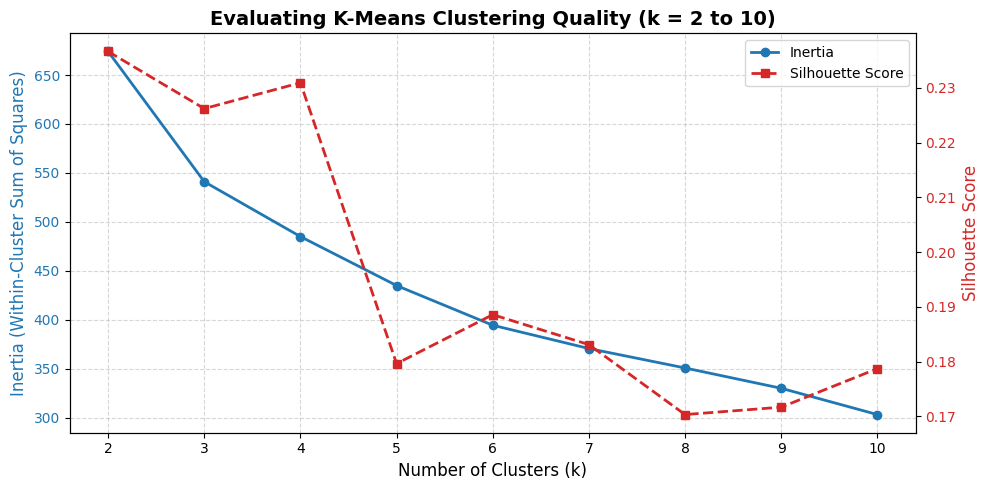

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Initialize lists to store inertia and silhouette scores
inertia_scores = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    # Use random_state=42 for reproducibility and n_init='10' to avoid warnings
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_scores.append(kmeans.inertia_)

    # Calculate silhouette score
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Plotting the results
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Inertia
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', color=color, fontsize=12)
line1 = ax1.plot(k_range, inertia_scores, marker='o', color=color, label='Inertia', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12)
line2 = ax2.plot(k_range, silhouette_scores, marker='s', color=color, linestyle='--', label='Silhouette Score', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

# Title and legend
plt.title('Evaluating K-Means Clustering Quality (k = 2 to 10)', fontsize=14, fontweight='bold')
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
for k in [3, 4]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    profile = features[cluster_cols].groupby(km.labels_).mean().round(2)
    profile['n_seasons'] = pd.Series(km.labels_).value_counts().sort_index().values
    print(f"\n--- k = {k} ---")
    display(profile)


--- k = 3 ---


,win_pct,avg_runs_margin,avg_wkts_margin,toss_conversion,home_edge,familiarity_edge,n_seasons
0,0.54,29.78,6.22,0.54,0.35,0.36,40
1,0.55,31.39,6.39,0.58,-0.03,-0.10,74
2,0.30,14.42,5.42,0.25,-0.06,-0.03,32



--- k = 4 ---


,win_pct,avg_runs_margin,avg_wkts_margin,toss_conversion,home_edge,familiarity_edge,n_seasons
0,0.54,29.78,6.22,0.54,0.35,0.36,40
1,0.32,26.81,2.36,0.22,-0.20,-0.20,6
2,0.32,11.77,6.34,0.29,-0.04,0.00,30
3,0.56,32.43,6.32,0.58,-0.03,-0.11,70
